# DBSCAN

En este notebook veremos cómo funciona **DBSCAN**, un algoritmo de clustering basado en densidad.

 **Idea clave**:
- Un cluster es una zona **densa** de puntos
- Los puntos aislados pueden considerarse **ruido**
- No necesitamos indicar previamente el número de clusters

Este ejemplo parte de unos datos en forma de media luna para ver claramente la diferencia con K-Means.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score


## 1. Generación de datos

Creamos datos no convexos para ver un caso donde DBSCAN puede funcionar mejor que K-Means.


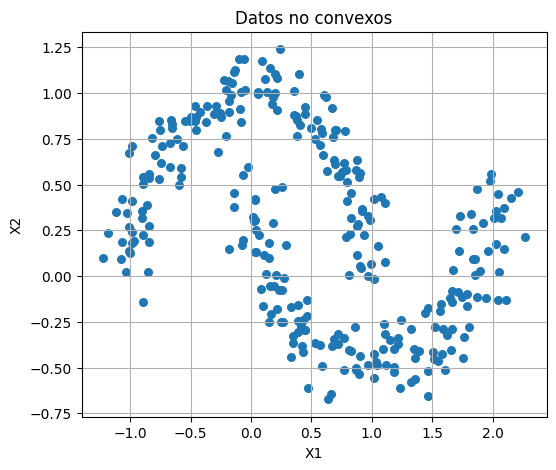

In [2]:
X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=30)
plt.title('Datos no convexos')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True)
plt.show()

## 2. Entrenamiento del modelo

DBSCAN necesita dos hiperparámetros:

- `eps`: radio de vecindad
- `min_samples`: número mínimo de puntos para considerar una zona como densa


In [3]:
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f'Número de clusters encontrados: {n_clusters}')
print(f'Número de puntos de ruido: {n_noise}')

Número de clusters encontrados: 2
Número de puntos de ruido: 0


## 3. Visualización del clustering

Los puntos con etiqueta `-1` son considerados ruido.


/tmp/ipykernel_2750/574851003.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels))


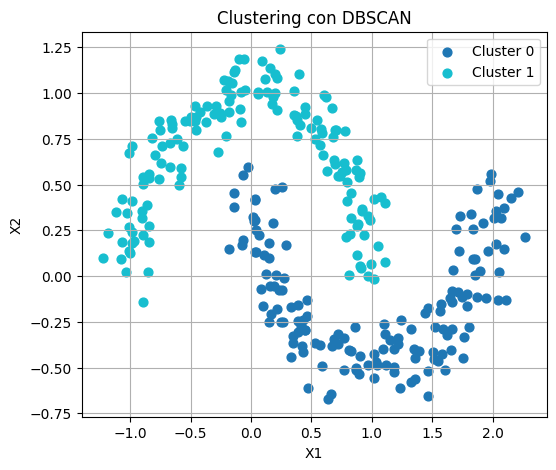

In [4]:
plt.figure(figsize=(6,5))
unique_labels = set(labels)
colors = plt.cm.get_cmap('tab10', len(unique_labels))

for label in unique_labels:
    mask = labels == label
    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        s=40,
        color='grey' if label == -1 else colors(label),
        label=f'Cluster {label}' if label != -1 else 'Ruido'
    )

plt.title('Clustering con DBSCAN')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.grid(True)
plt.show()

## 4. Comparación de distintos valores de `eps`

Vamos a ver cómo cambia el resultado al modificar `eps`.


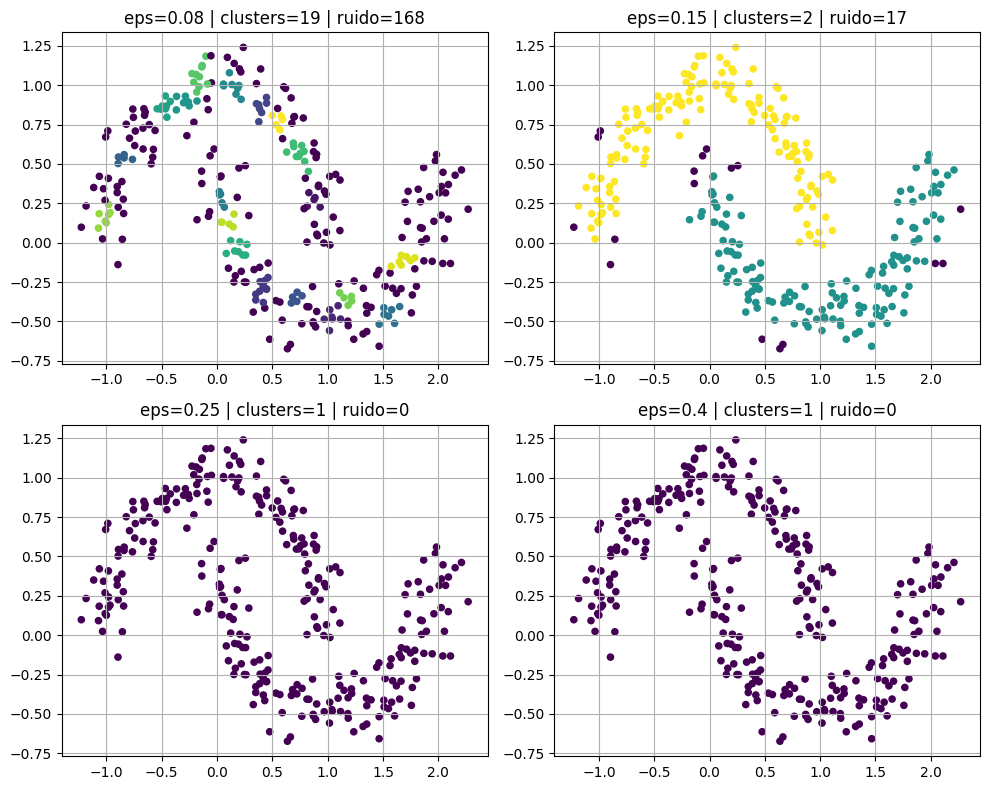

In [5]:
eps_values = [0.08, 0.15, 0.25, 0.4]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for i, eps in enumerate(eps_values):
    model = DBSCAN(eps=eps, min_samples=5)
    labels_eps = model.fit_predict(X)
    n_clusters_eps = len(set(labels_eps)) - (1 if -1 in labels_eps else 0)
    n_noise_eps = list(labels_eps).count(-1)

    axes[i].scatter(X[:,0], X[:,1], c=labels_eps, cmap='viridis', s=20)
    axes[i].set_title(f'eps={eps} | clusters={n_clusters_eps} | ruido={n_noise_eps}')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

## 5. Comparación de distintos valores de `min_samples`

Ahora mantenemos `eps` fijo y cambiamos `min_samples`.


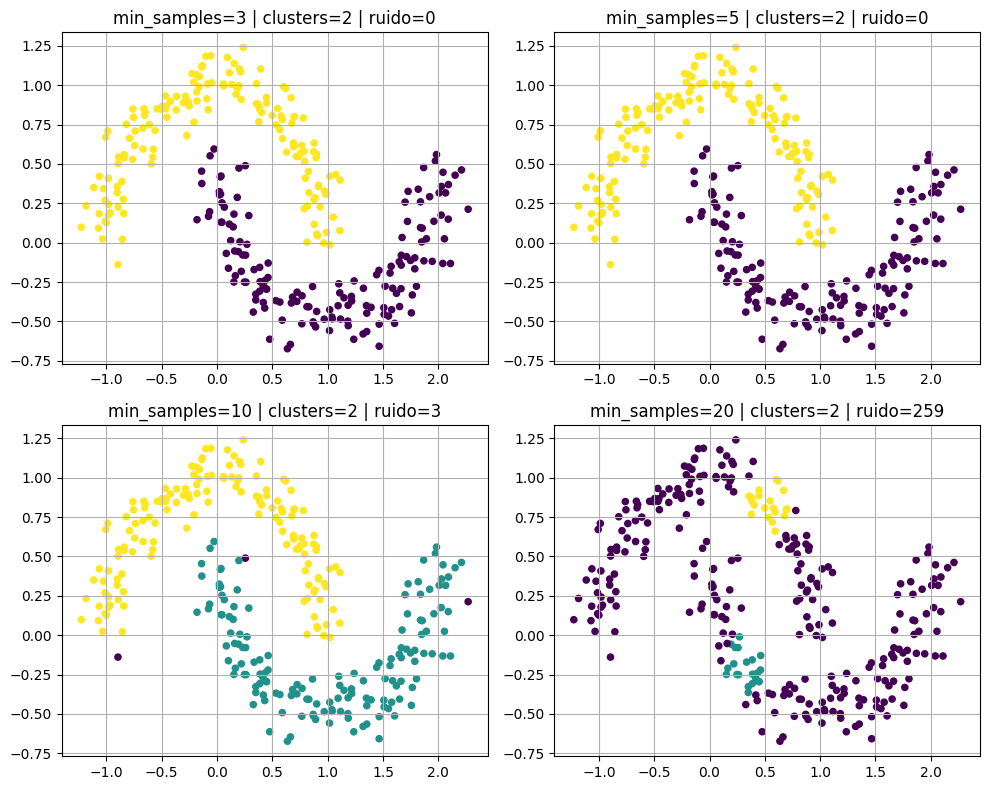

In [6]:
min_samples_values = [3, 5, 10, 20]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for i, m in enumerate(min_samples_values):
    model = DBSCAN(eps=0.2, min_samples=m)
    labels_m = model.fit_predict(X)
    n_clusters_m = len(set(labels_m)) - (1 if -1 in labels_m else 0)
    n_noise_m = list(labels_m).count(-1)

    axes[i].scatter(X[:,0], X[:,1], c=labels_m, cmap='viridis', s=20)
    axes[i].set_title(f'min_samples={m} | clusters={n_clusters_m} | ruido={n_noise_m}')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

## 6. Silhouette Score

Cuando DBSCAN encuentra más de un cluster y no asigna todos los puntos al mismo grupo, podemos calcular el **Silhouette Score**.

En algunos casos no se puede calcular o no es tan informativo, especialmente si hay mucho ruido.


In [7]:
labels_validos = labels[labels != -1]
X_validos = X[labels != -1]

if len(set(labels_validos)) > 1:
    sil = silhouette_score(X_validos, labels_validos)
    print(f'Silhouette score (sin ruido): {sil:.4f}')
else:
    print('No se puede calcular Silhouette Score con la configuración actual.')

Silhouette score (sin ruido): 0.3241


## 7. Idea importante

DBSCAN clasifica los puntos en:

- **puntos núcleo**: tienen suficientes vecinos en su entorno
- **puntos frontera**: están cerca de una región densa
- **ruido**: puntos aislados

Por eso DBSCAN puede detectar formas complejas y también outliers.


## 8. Conclusiones

- DBSCAN no necesita indicar previamente el número de clusters
- Detecta bien formas arbitrarias, como las medias lunas
- Puede identificar puntos de ruido
- Es sensible a la elección de `eps` y `min_samples`


## 9. Ejercicios

1. Probar otros valores de `eps`
2. Probar otros valores de `min_samples`
3. Comparar este resultado con K-Means sobre los mismos datos
4. Explicar por qué DBSCAN funciona mejor que K-Means en este ejemplo
